Hands-On Lab: Sprint 1 Kickoff & Baseline       
● Step 1: Complete Sprint 1 planning: confirm the goal and select the first backlog tasks.      
● Step 2: Finalize the project dataset and complete a brief EDA in the project notebook.        
● Step 3: Train a simple baseline model (e.g. logistic/linear regression from Week 3) and record its metric.        
● Step 4: Commit the baseline notebook to a feature branch and open a draft pull request.       
● Step 5: In Markdown, state the baseline score every later model must beat.        

#### Load, Clean & split data:

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,recall_score, classification_report, confusion_matrix, f1_score


In [112]:
df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 1\Data\heart_disease.csv" )

In [113]:
print (df.shape,"\n")

print ("Null values: \n", df.isna().sum(),"\n")

print("duplicates :",df.duplicated().sum(),"\n")

(10000, 21) 

Null values: 
 Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64 

duplicates : 0 



In [114]:
print ("Information:")
df.info()

Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption 

In [115]:
print (df.columns)

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')


In [116]:
categorical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['str']).columns.tolist()

numerical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['int64','float64']).columns.tolist()

print("categorical columns name: ")
print(categorical_cols)

print("\nnumerical columns name: ")
print(numerical_cols)

categorical columns name: 
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

numerical columns name: 
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']


we have some missing values so we deal with them:   

- numeric: fill with median.    
- categorical: fill with mode.    

for Alcohol Consumption we rectify the data since none is a category rather than a null value.

In [117]:
print("Alcohol Consumption categories Before: ", df['Alcohol Consumption'].unique())

# numnerical 
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# categorical
for col in categorical_cols: 
    
    if col == "Alcohol Consumption":
        df[col] = df[col].fillna("Zero")
        
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    
print ("\nAlcohol Consumption categories After: ", df['Alcohol Consumption'].unique())
print ("\nNull values 'after': \n", df.isna().sum(),"\n")


Alcohol Consumption categories Before:  <StringArray>
['High', 'Medium', 'Low', nan]
Length: 4, dtype: str

Alcohol Consumption categories After:  <StringArray>
['High', 'Medium', 'Low', 'Zero']
Length: 4, dtype: str

Null values 'after': 
 Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64 



In [118]:
X = df.drop(columns ='Heart Disease Status')
y = df['Heart Disease Status']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify= y)

print(y_train.unique(),"\n")
print(y_train.value_counts(),"\n")
print(y_train.dtype)

<StringArray>
['No', 'Yes']
Length: 2, dtype: str 

Heart Disease Status
No     6400
Yes    1600
Name: count, dtype: int64 

str


#### Brief EDA

##### Target class (Heart Disease Status) distribution:

In [119]:
print(df["Heart Disease Status"].value_counts(),"\n")
print(df["Heart Disease Status"].value_counts(normalize=True))

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64 

Heart Disease Status
No     0.8
Yes    0.2
Name: proportion, dtype: float64


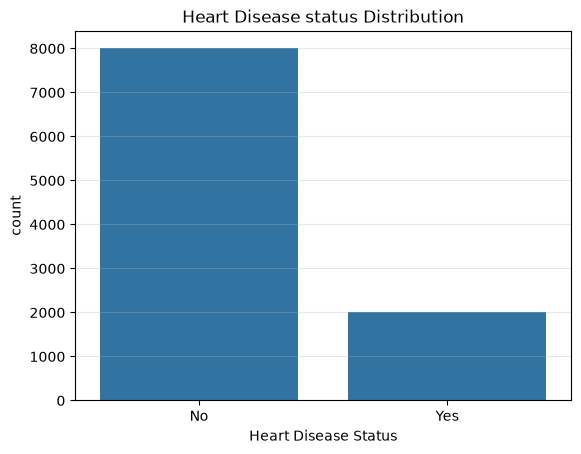

In [120]:
sns.countplot(data = df, x ="Heart Disease Status")
plt.title('Heart Disease status Distribution')
plt.grid(axis= 'y',alpha=.3)
plt.show()


##### Numerical features distributions:

**Histograms**

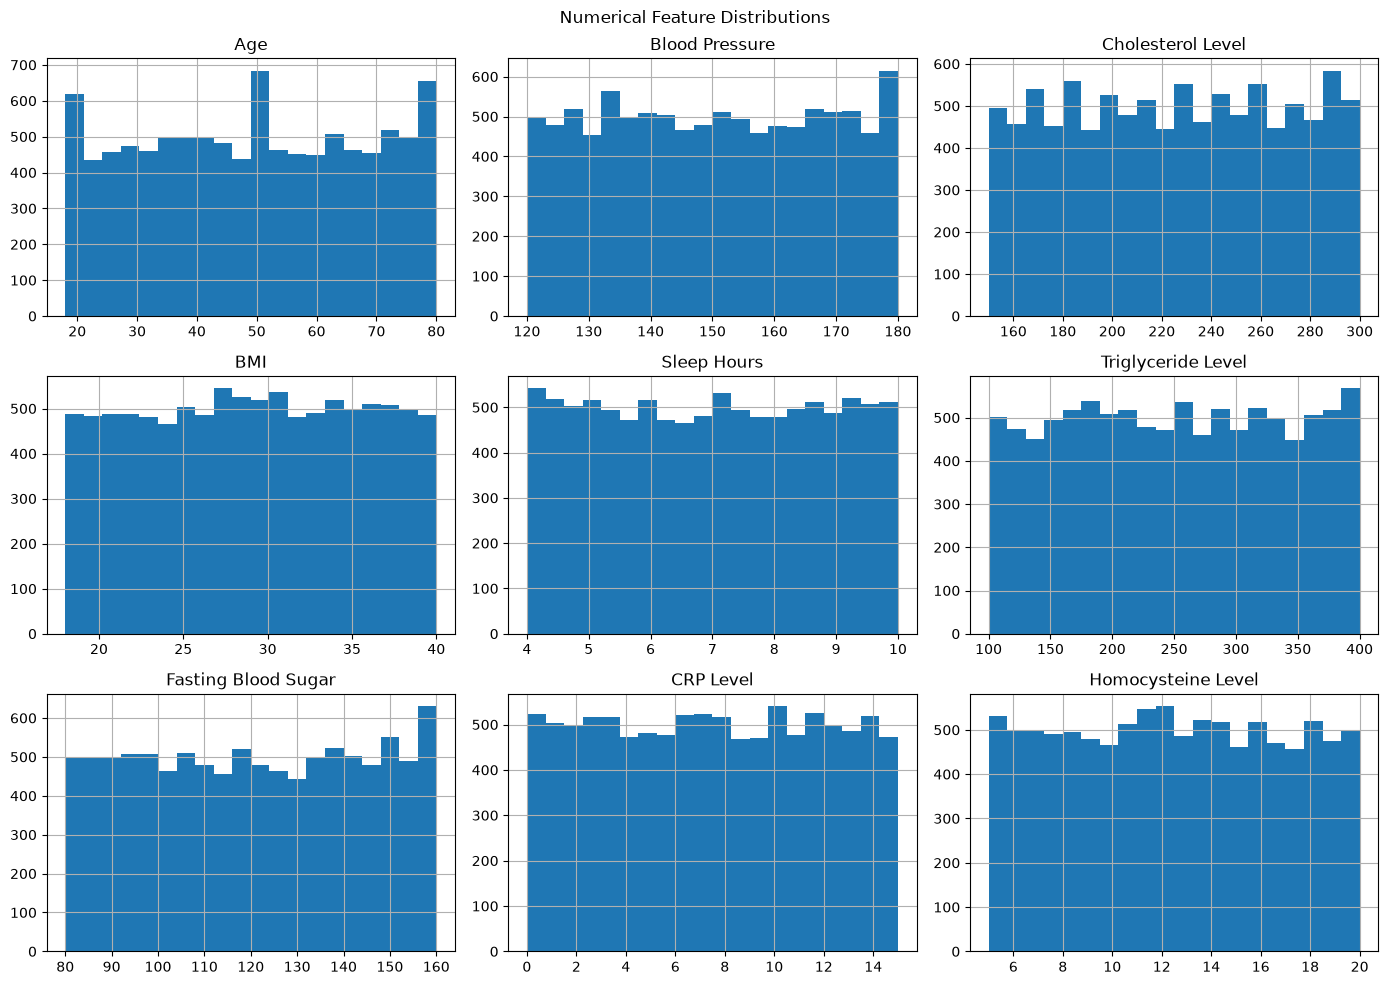

In [121]:
df[numerical_cols].hist(figsize=(14, 10),bins=20)

plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

##### Numerical features vs Target distributions:

**Box plots**

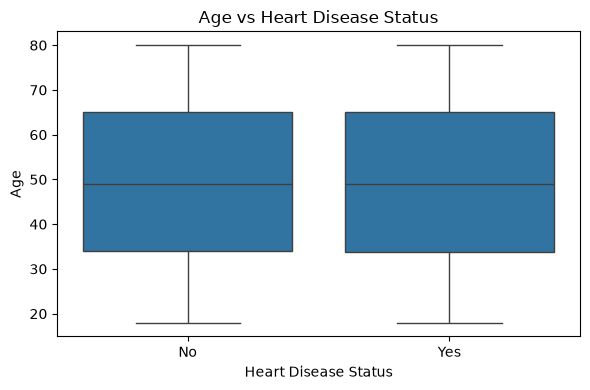

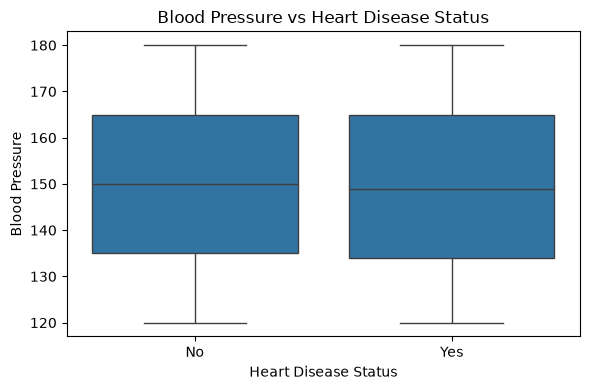

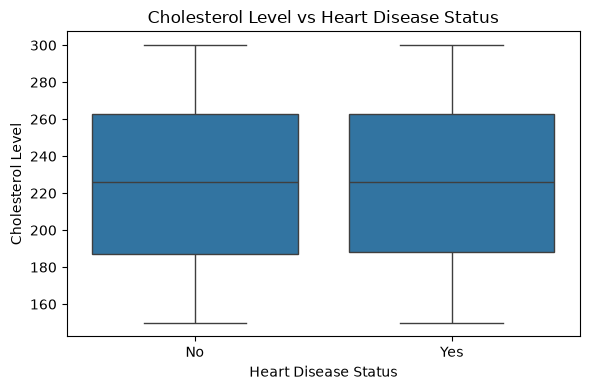

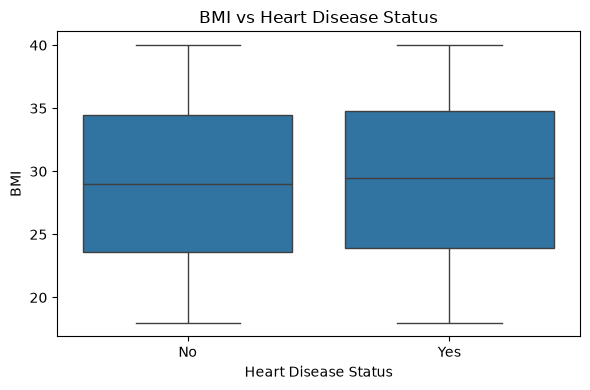

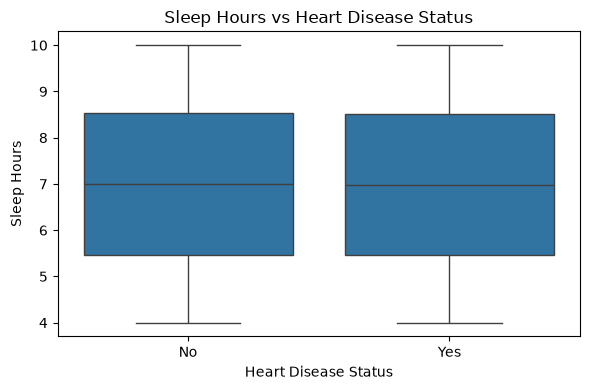

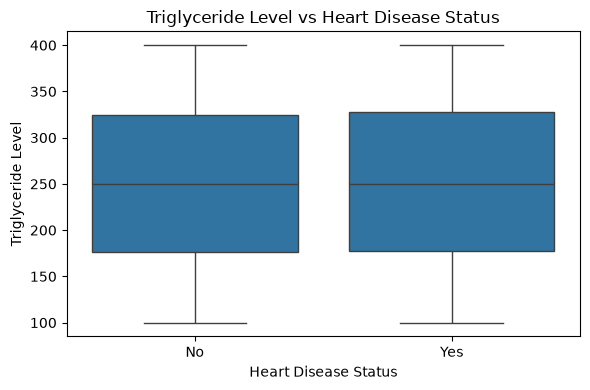

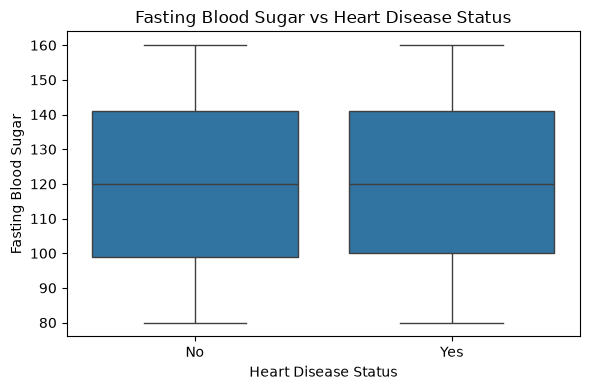

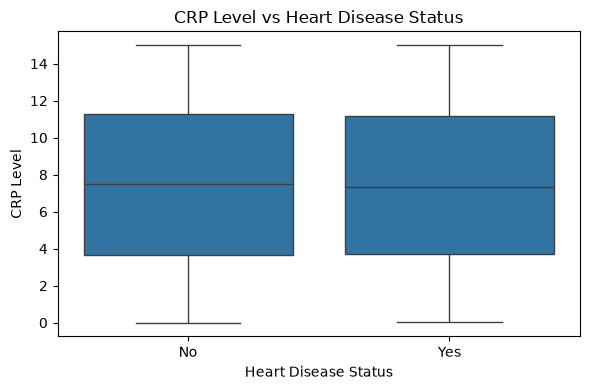

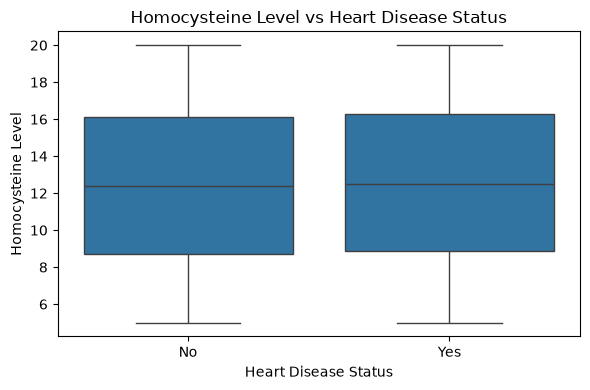

In [122]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Heart Disease Status", y =col, )
    
    plt.title(f"{col} vs Heart Disease Status")
    plt.tight_layout()
    plt.show()

##### Categorical features vs Target distributuins:
**Count plots**

In [123]:
# just selecting a part of them.
selected_categorical = [
    "Gender",
    "Smoking",
    "Exercise Habits",
    "Diabetes",
    "Family Heart Disease",
    "High Blood Pressure"
]

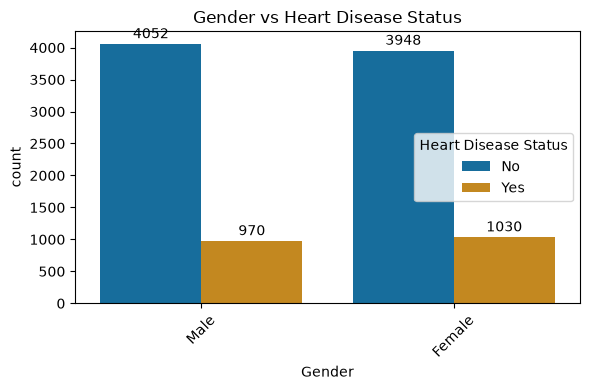

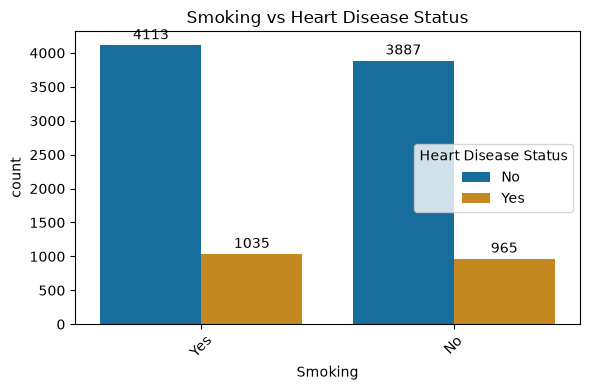

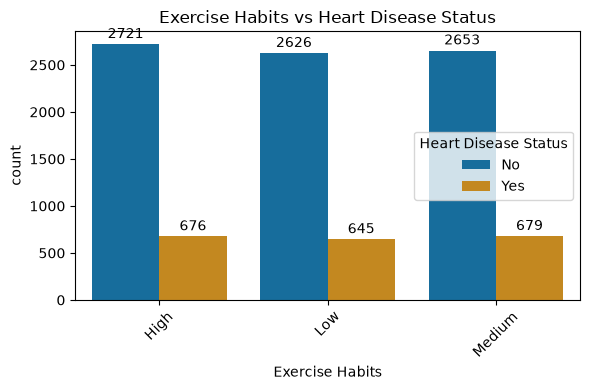

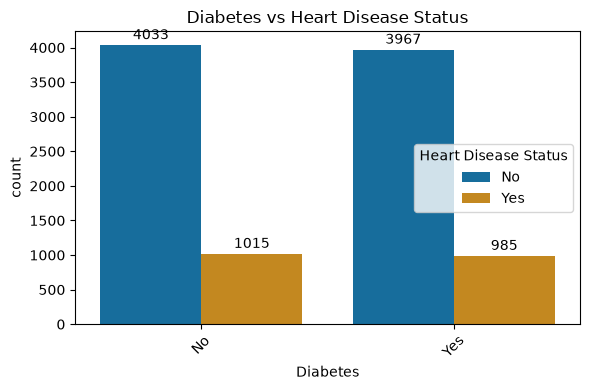

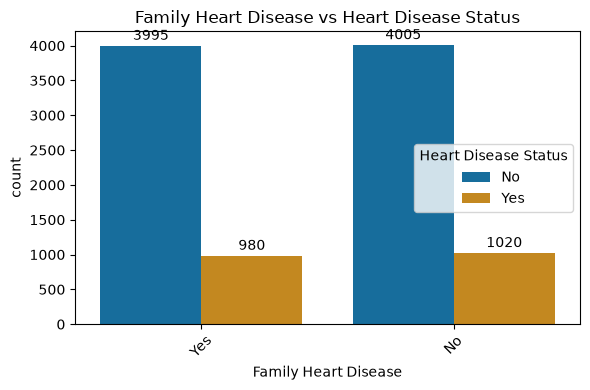

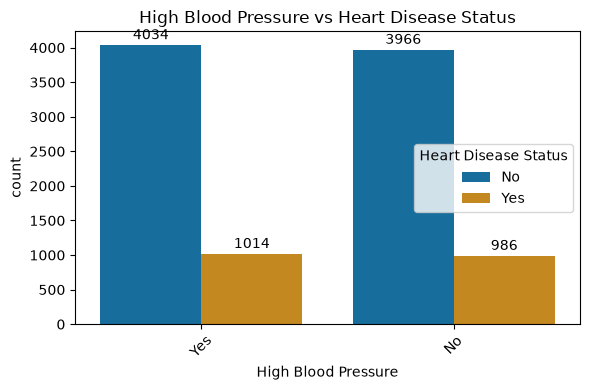

In [124]:
for col in selected_categorical:
    plt.figure(figsize=(6,4))
    
    ax = sns.countplot(data =df ,x=col, hue= 'Heart Disease Status', palette='colorblind')
    
    # show the value in top of each box
    for container in ax.containers:
        ax.bar_label(container, padding=2)
    
    plt.title(f"{col} vs Heart Disease Status")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()
    


##### Correlation matrix:
**correlation heeat map**

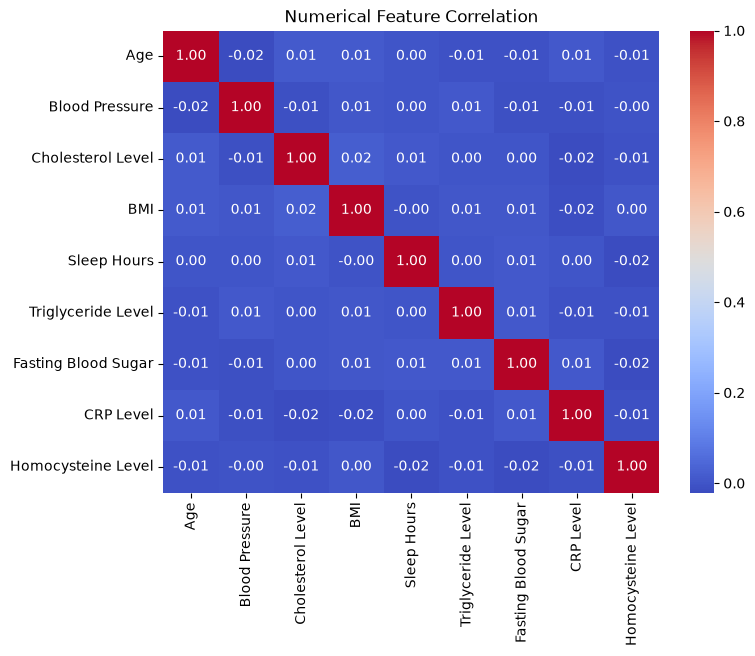

In [125]:
plt.figure(figsize=(8, 6))

corr = df[numerical_cols].corr()

sns.heatmap(corr , annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Numerical Feature Correlation")
plt.show()

There isn't any substantial correlation between the numerical features.

#### Baseline Model: 

##### Base:

In [126]:
preprocessor = ColumnTransformer([("num",
                                 StandardScaler(),
                                 numerical_cols)
                                 ,
                                ("col",
                                 OneHotEncoder(handle_unknown="ignore"),
                                 categorical_cols)
                                 ])

In [139]:
lr_pipe = Pipeline([ ("preprocessor", preprocessor)
                 ,
                  ("model", LogisticRegression(max_iter=1000, random_state=42) )])

In [ ]:
# training cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_Scores = cross_val_score(lr_pipe, X_train, y_train ,cv=cv, scoring= "f1_macro", n_jobs=-1)

print(f1_Scores)
print("Mean F1 score: ",f1_Scores.mean())


acc_Scores = cross_val_score(lr_pipe, X_train, y_train ,cv=cv, scoring= "accuracy", n_jobs=-1)

print("")
print(acc_Scores)
print("Mean accuracy score: ",acc_Scores.mean())

[0.44444444 0.44444444 0.44444444 0.44444444 0.44444444]
Mean F1 score:  0.4444444444444445

[0.8 0.8 0.8 0.8 0.8]
Mean accuracy score:  0.8


In [ ]:
# Test 
lr_pipe.fit(X_train,y_train)

lr_pred = lr_pipe.predict(X_test)

acc = accuracy_score(y_test,lr_pred)

print("TEST Accuracy score: ", acc)

TEST Accuracy score:  0.8


In [147]:
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

[[1600    0]
 [ 400    0]]
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1600
         Yes       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

##### Slightly imporved baseline (Balanced):

In [143]:
lr_balanced_pipe = Pipeline([ ("preprocessor", preprocessor)
                 ,
                  ("model", LogisticRegression(max_iter=1000, random_state=42,class_weight="balanced") )])

In [ ]:
# training cross validation
f1_balanced_Scores = cross_val_score(lr_balanced_pipe, X_train, y_train ,cv=cv, scoring= "f1_macro", n_jobs=-1)

print(f1_balanced_Scores)
print("Mean F1 score: ",f1_balanced_Scores.mean())


acc_balanced_Scores = cross_val_score(lr_balanced_pipe, X_train, y_train ,cv=cv, scoring= "accuracy", n_jobs=-1)

print("")
print(acc_balanced_Scores)
print("Mean accuracy score: ",acc_balanced_Scores.mean())

[0.46008804 0.45312119 0.43587944 0.46251323 0.46726705]
Mean F1 score:  0.45577379093800835

[0.506875 0.51     0.4875   0.51375  0.5275  ]
Mean accuracy score:  0.5091249999999999


In [145]:
# Test 
lr_balanced_pipe.fit(X_train,y_train)

lr_balanced_pred = lr_balanced_pipe.predict(X_test)

acc = accuracy_score(y_test,lr_balanced_pred)

print("TEST Accuracy score: ", acc)

TEST Accuracy score:  0.504


In [146]:
print(confusion_matrix(y_test, lr_balanced_pred))
print(classification_report(y_test, lr_balanced_pred))

[[825 775]
 [217 183]]
              precision    recall  f1-score   support

          No       0.79      0.52      0.62      1600
         Yes       0.19      0.46      0.27       400

    accuracy                           0.50      2000
   macro avg       0.49      0.49      0.45      2000
weighted avg       0.67      0.50      0.55      2000



##### conclusion:
The initial Logistic Regression baseline achieved 80% accuracy but a macro F1 score of only 0.444.      
 This indicates that the model is strongly biased toward the majority class and likely predicts only the dominant class.        
  Therefore, accuracy alone is misleading for this imbalanced dataset.      

it changed when i add `class_weight="balanced"` to the logistic regression hyperparameters.     
`class_weight="balanced"` caused a big drop in accuracy, but it improved the model's ability to detect heart disease cases.   


| Model behavior | Accuracy | Macro F1 | Yes Recall |
| -------------- | -------: | -------: | ---------: |
| Original LR    |    ~0.80 |    ~0.44 |   ~0 |
| Balanced LR    |    ~0.50 |    ~0.45 |       0.46 |


  